In [20]:
import pandas as pd
import plotly.express as px

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df_2023 = pd.read_csv('cleaned_df.csv')
df_2023.head()

,State,City,Street,Zipcode,Bedroom,Bathroom,Area,PPSq,LotArea,MarketEstimate,RentEstimate,Latitude,Longitude,ListedPrice
0,AL,Saraland,Scott Dr,36571.0,4.0,2.0,1614.0,148.636927,0.3805,240600.0,1599.0,30.819534,-88.095960,239900.0
1,AL,Robertsdale,Cowpen Creek Rd,36567.0,3.0,2.0,1800.0,144.388889,3.2000,NaN,NaN,30.590004,-87.580376,259900.0
2,AL,Gulf Shores,Spinnaker Dr #201,36542.0,2.0,2.0,1250.0,274.000000,NaN,NaN,NaN,30.284956,-87.747920,342500.0
3,AL,Chelsea,Mallet Way,35043.0,3.0,3.0,2224.0,150.629496,0.2600,336200.0,1932.0,33.357986,-86.608700,335000.0
4,AL,Huntsville,Turtlebrook Ct,35811.0,3.0,2.0,1225.0,204.081633,NaN,222700.0,1679.0,34.775517,-86.440700,250000.0


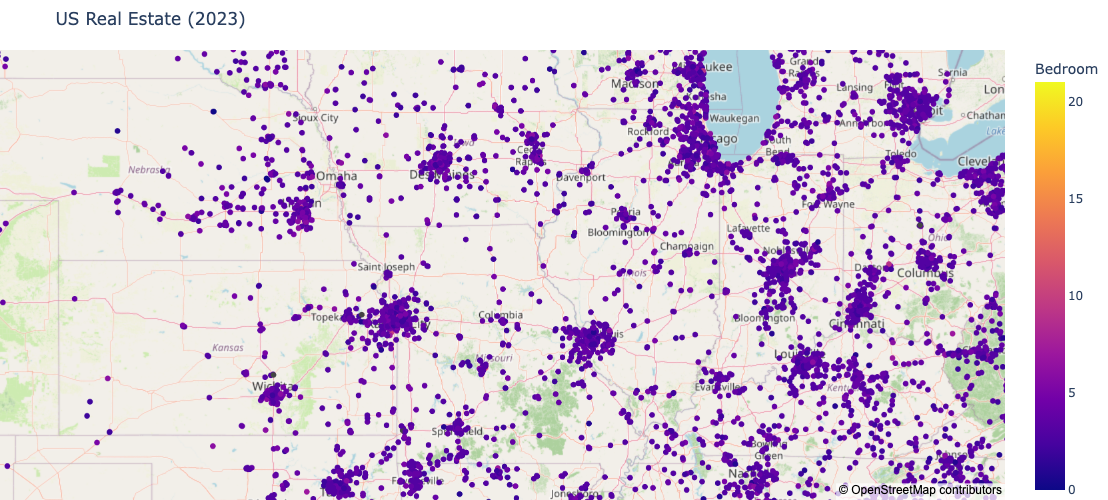

In [9]:
fig = px.scatter_map(
    df_2023,
    lat='Latitude',
    lon='Longitude',
    color='Bedroom',
    hover_name="ListedPrice",
    zoom=5,
    center={
        "lat": df_2023["Latitude"].mean(),
        "lon": df_2023["Longitude"].mean()
    },
    height=500,
    width=700,
    title="US Real Estate (2023)"
)
fig.update_layout(
    map_style="open-street-map",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()


In [8]:
df_2023.columns

Index(['State', 'City', 'Street', 'Zipcode', 'Bedroom', 'Bathroom', 'Area',
       'PPSq', 'LotArea', 'MarketEstimate', 'RentEstimate', 'Latitude',
       'Longitude', 'ListedPrice'],
      dtype='object')

In [17]:
#state_df = df_2023.groupby('State').agg({'ListedPrice':'mean'})
state_df = df_2023[['State', 'Bedroom', 'Bathroom', 'Area', 'MarketEstimate', 'RentEstimate', 'Latitude',
       'Longitude', 'ListedPrice']].groupby('State').mean().round(2)
state_df.head()

,Bedroom,Bathroom,Area,MarketEstimate,RentEstimate,Latitude,Longitude,ListedPrice
State,,,,,,,,
AK,3.24,2.40,2067.49,468900.43,2667.16,61.71,-148.02,482656.10
AL,3.33,2.32,1911.48,245914.35,1701.43,32.48,-86.89,269243.76
AR,3.27,2.31,1964.15,286516.56,1725.04,35.25,-92.68,327884.88
AZ,3.42,2.47,2147.77,504818.75,2449.84,33.35,-111.90,663903.92
CA,3.56,2.65,2130.44,1252249.89,4563.94,35.69,-119.33,1258653.26


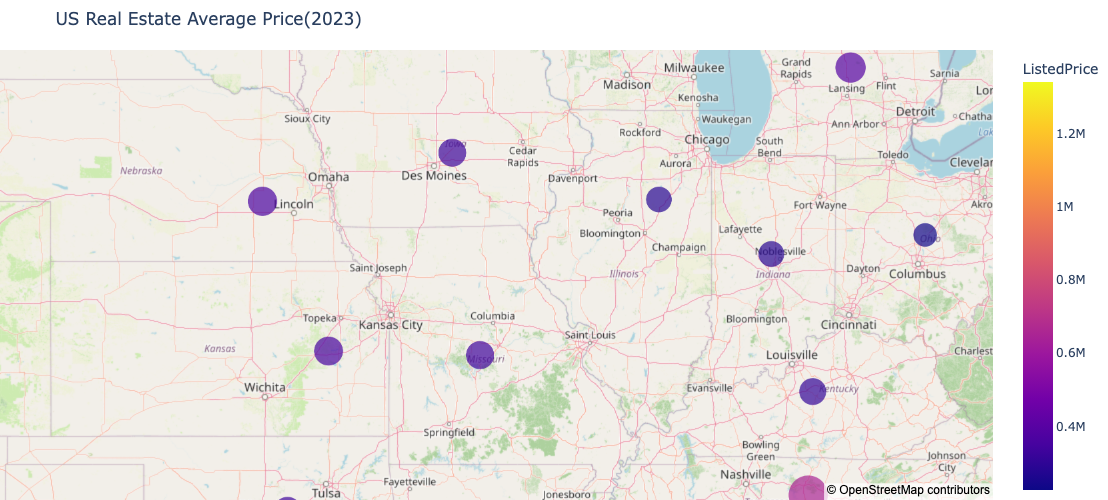

In [20]:
fig1 = px.scatter_map(
    state_df,
    lat='Latitude',
    lon='Longitude',
    color='ListedPrice',
    size="ListedPrice",              # Bubble size
    size_max=40,
    hover_name="ListedPrice",
    zoom=5,
    center={
        "lat": state_df["Latitude"].mean(),
        "lon": state_df["Longitude"].mean()
    },
    height=500,
    width=700,
    title="US Real Estate Average Price(2023)"
)
fig1.update_layout(
    map_style="open-street-map",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig1.show()


In [4]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22681 entries, 0 to 22680
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           22681 non-null  object 
 1   City            22681 non-null  object 
 2   Street          22681 non-null  object 
 3   Zipcode         22681 non-null  float64
 4   Bedroom         22667 non-null  float64
 5   Bathroom        22647 non-null  float64
 6   Area            22681 non-null  float64
 7   PPSq            22681 non-null  float64
 8   LotArea         21779 non-null  float64
 9   MarketEstimate  15445 non-null  float64
 10  RentEstimate    16705 non-null  float64
 11  Latitude        22681 non-null  float64
 12  Longitude       22681 non-null  float64
 13  ListedPrice     22681 non-null  float64
dtypes: float64(11), object(3)
memory usage: 2.4+ MB


In [42]:
df_2023.loc[15741]

State                       OH
City                   Bedford
Street            Palmetto Ave
Zipcode                44146.0
Bedroom                    4.0
Bathroom                   2.0
Area                    2250.0
PPSq                 92.222222
LotArea                    NaN
MarketEstimate             NaN
RentEstimate               NaN
Latitude              41.39695
Longitude            -81.54584
ListedPrice           207500.0
Name: 15741, dtype: object

### Linear Regression


when you dropna, you drop the row actually.   
Two dataframes may have different indexes after that like.     
[1a,2b,3c,4d,5e] and [1A,3B,4C,5D,6E].      
when you concat them, concat is index based, so what will the concat be.  
1:a A    
2:b nan  
3:c B  
4:d C  
5:e D  
6:nan E  


In [52]:
 
df_linear = df_2023[['State','Bedroom','Bathroom','Area','LotArea','Latitude','Longitude','ListedPrice']].dropna().reset_index(drop=True)
df_linear.head()

,State,Bedroom,Bathroom,Area,LotArea,Latitude,Longitude,ListedPrice
0,AL,4.0,2.0,1614.0,0.3805,30.819534,-88.095960,239900.0
1,AL,3.0,2.0,1800.0,3.2000,30.590004,-87.580376,259900.0
2,AL,3.0,3.0,2224.0,0.2600,33.357986,-86.608700,335000.0
3,AL,3.0,2.0,1564.0,0.2000,32.372746,-86.165115,151000.0
4,AL,3.0,2.0,1717.0,0.3800,34.210014,-86.136690,239000.0


### OneHotEncoder

In [8]:
encoder = OneHotEncoder(drop='first',sparse_output=False)

In [53]:
state_encoded = encoder.fit_transform(df_linear[['State']])

In [54]:
df_encoded = pd.DataFrame(state_encoded,columns=encoder.get_feature_names_out(['State']))

In [46]:
df_linear.index

Index([    0,     1,     3,     5,     6,     7,     8,     9,    11,    12,
       ...
       22671, 22672, 22673, 22674, 22675, 22676, 22677, 22678, 22679, 22680],
      dtype='int64', length=21745)

In [47]:
df_encoded.index

RangeIndex(start=0, stop=21745, step=1)

In [55]:
df_encoded2 = pd.concat([df_linear.drop(columns='State'),df_encoded], axis=1)
df_encoded2.head()

,Bedroom,Bathroom,Area,LotArea,Latitude,Longitude,ListedPrice,State_AL,State_AR,State_AZ,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,4.0,2.0,1614.0,0.3805,30.819534,-88.095960,239900.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,2.0,1800.0,3.2000,30.590004,-87.580376,259900.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,3.0,2224.0,0.2600,33.357986,-86.608700,335000.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,2.0,1564.0,0.2000,32.372746,-86.165115,151000.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,2.0,1717.0,0.3800,34.210014,-86.136690,239000.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### StandardScaler

In [57]:
X = df_encoded2.drop(columns='ListedPrice')
y = df_encoded2['ListedPrice']

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.head()

,Bedroom,Bathroom,Area,LotArea,Latitude,Longitude,State_AL,State_AR,State_AZ,State_CA,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
21111,3.0,2.0,1900.0,67.550000,43.439884,-91.180430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1947,5.0,3.0,2038.0,0.057300,37.728836,-122.390710,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21128,5.0,2.0,1624.0,1.000000,45.057644,-87.620730,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2225,3.0,3.0,1763.0,0.054086,38.646404,-121.543760,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12353,3.0,2.0,1586.0,0.150000,36.242397,-115.214096,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17396 entries, 21111 to 15795
Data columns (total 54 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Bedroom    17396 non-null  float64
 1   Bathroom   17396 non-null  float64
 2   Area       17396 non-null  float64
 3   LotArea    17396 non-null  float64
 4   Latitude   17396 non-null  float64
 5   Longitude  17396 non-null  float64
 6   State_AL   17396 non-null  float64
 7   State_AR   17396 non-null  float64
 8   State_AZ   17396 non-null  float64
 9   State_CA   17396 non-null  float64
 10  State_CO   17396 non-null  float64
 11  State_CT   17396 non-null  float64
 12  State_DE   17396 non-null  float64
 13  State_FL   17396 non-null  float64
 14  State_GA   17396 non-null  float64
 15  State_IA   17396 non-null  float64
 16  State_ID   17396 non-null  float64
 17  State_IL   17396 non-null  float64
 18  State_IN   17396 non-null  float64
 19  State_KS   17396 non-null  float64
 20  State_K

In [61]:
#fit_transform() is used on the training set.
#transform() is used on the test set.
#This prevents information from the test set from influencing the scaling (data leakage).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Linear Regression

In [62]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [72]:
y_pred = model.predict(X_test_scaled)


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²  : {r2:.3f}")

MAE : $362,354
RMSE: $883,741
R²  : 0.471


In [63]:
x = pd.DataFrame({"meow": [3, 7, 9]})
y = pd.DataFrame({"fido": [2,11]})

In [67]:
x = x.iloc[[0,2]]
x

,meow
0,3
2,9


In [65]:
y

,fido
0,2
1,11


In [69]:
pd.concat([x, y], axis="columns")

,meow,fido
0,3.0,2.0
2,9.0,NaN
1,NaN,11.0


In [71]:
x["meow"] * y["fido"]

0    6.0
1    NaN
2    NaN
dtype: float64

### Actual vs. Predicted (Most Recommended)

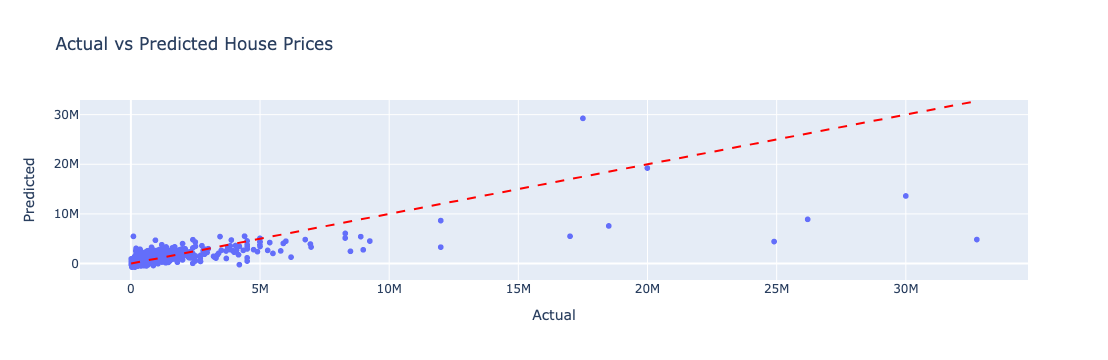

In [74]:
import plotly.express as px
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

fig = px.scatter(
    results,
    x='Actual',
    y='Predicted',
    title='Actual vs Predicted House Prices'
)

# Add the perfect prediction line
fig.add_shape(
    type='line',
    x0=results['Actual'].min(),
    y0=results['Actual'].min(),
    x1=results['Actual'].max(),
    y1=results['Actual'].max(),
    line=dict(color='red', dash='dash')
)

fig.show()

### Residual Plot

This helps identify patterns in the prediction errors.

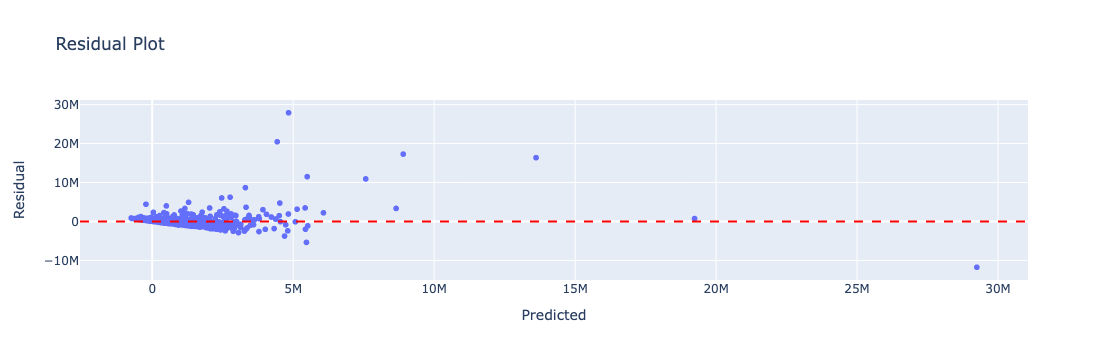

In [75]:
results['Residual'] = results['Actual'] - results['Predicted']

fig = px.scatter(
    results,
    x='Predicted',
    y='Residual',
    title='Residual Plot'
)

fig.add_hline(y=0, line_dash='dash', line_color='red')

fig.show()

In [78]:
X_test['Prediction'] = y_pred

fig = px.scatter(
    X_test,
    x='Area',
    y='ListedPrice',
    title='Linear Regression'
)

fig.add_scatter(
    x=X_test['Area'],
    y=X_test['Prediction'],
    mode='lines',
    name='Regression Line',
    line=dict(color='red')
)

fig.show()

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['Bedroom', 'Bathroom', 'Area', 'LotArea', 'Latitude', 'Longitude', 'State_AL', 'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DE', 'State_FL', 'State_GA', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY', 'Prediction'] but received: ListedPrice

### Feature Importance (Coefficients)

A great way to visualize a multiple linear regression model is by plotting the coefficients.

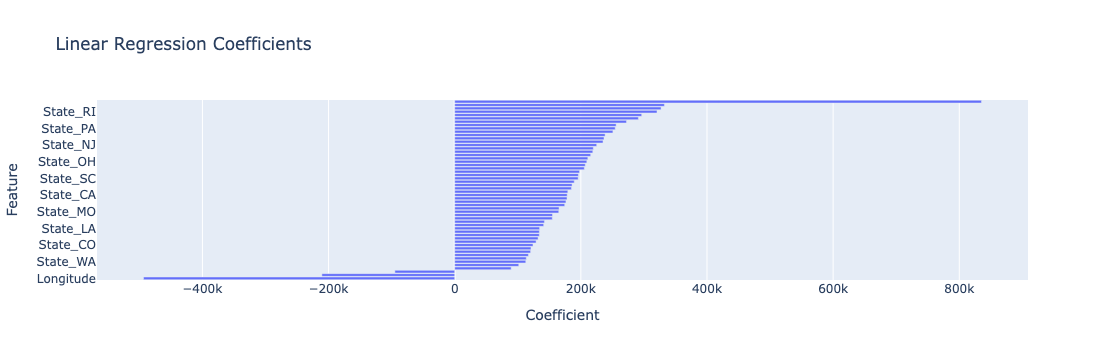

In [77]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coef_df = coef_df.sort_values('Coefficient')

fig = px.bar(
    coef_df,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title='Linear Regression Coefficients'
)

fig.show()